# Data Preprocessing
**Sleep Health and Lifestyle Dataset**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [4]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


In [5]:
print('Sleep Disorder distribution:')
print(df['Sleep Disorder'].value_counts(dropna=False))


Sleep Disorder distribution:
Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


## Encoding & Cleaning

In [6]:
from sklearn.preprocessing import LabelEncoder

df = df.drop('Person ID', axis=1)
df = df.drop('Blood Pressure', axis=1)  
# convert text columns to numbers using labelencoder()
le = LabelEncoder()
df['Gender']        = le.fit_transform(df['Gender'])
df['Occupation']    = le.fit_transform(df['Occupation'])
df['BMI Category']  = le.fit_transform(df['BMI Category'])

# NaN in Sleep Disorder means no disorder
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
df['Sleep Disorder'] = le.fit_transform(df['Sleep Disorder'])  # Insomnia=0, None=1, Sleep Apnea=2

df.head()

,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder
0,1,27,9,6.1,6,42,6,3,77,4200,1
1,1,28,1,6.2,6,60,8,0,75,10000,1
2,1,28,1,6.2,6,60,8,0,75,10000,1
3,1,28,6,5.9,4,30,8,2,85,3000,2
4,1,28,6,5.9,4,30,8,2,85,3000,2


## Features & Targets
Classification -> Targer : Sleep Disorder 


Regression-> Target :  Quality of Sleep 

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(['Sleep Disorder', 'Quality of Sleep'], axis=1)

# Classification
y_cls = df['Sleep Disorder']
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(X, y_cls, test_size=0.2, random_state=42)

# Regression
y_reg = df['Quality of Sleep']
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

print('Features:', list(X.columns))
print()
print('Classification splits — Train:', X_cls_train.shape, '| Test:', X_cls_test.shape)
print('Regression splits    — Train:', X_reg_train.shape, '| Test:', X_reg_test.shape)

Features: ['Gender', 'Age', 'Occupation', 'Sleep Duration', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Heart Rate', 'Daily Steps']

Classification splits — Train: (299, 9) | Test: (75, 9)
Regression splits    — Train: (299, 9) | Test: (75, 9)


## Visualizations

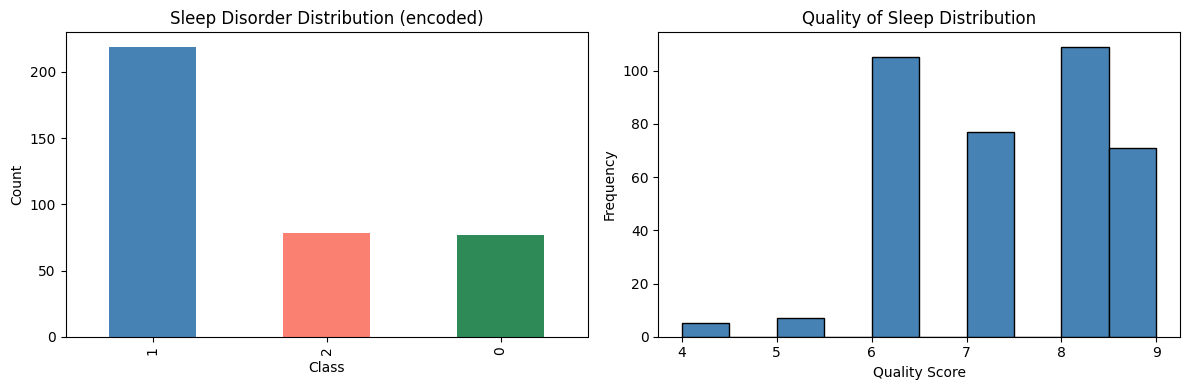

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

y_cls.value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon', 'seagreen'])
axes[0].set_title('Sleep Disorder Distribution (encoded)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

y_reg.plot(kind='hist', bins=10, ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Quality of Sleep Distribution')
axes[1].set_xlabel('Quality Score')

plt.tight_layout()
plt.show()